In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import binomtest


In [2]:
import json
from pathlib import Path


def _extract_metrics_one(result_dict):
    """
    result_dict is one question/task result for ONE model, like your question_1 dict:
      {classification_report:..., confusion_matrix:..., roc_curve:..., feature_importances:...}
    """
    cr = result_dict.get("classification_report", {}) or {}
    out = {}

    # Common overall metrics
    out["accuracy"] = cr.get("accuracy", np.nan)

    macro = cr.get("macro avg", {}) or {}
    out["macro_precision"] = macro.get("precision", np.nan)
    out["macro_recall"] = macro.get("recall", np.nan)
    out["macro_f1"] = macro.get("f1-score", np.nan)

    wavg = cr.get("weighted avg", {}) or {}
    out["weighted_precision"] = wavg.get("precision", np.nan)
    out["weighted_recall"] = wavg.get("recall", np.nan)
    out["weighted_f1"] = wavg.get("f1-score", np.nan)

    # Per-class f1 (optional)
    for k, v in cr.items():
        if isinstance(v, dict) and "f1-score" in v:
            out[f"f1_{k}"] = v.get("f1-score", np.nan)

    # ROC AUC if present
    roc = result_dict.get("roc_curve", {}) or {}
    if "binary" in roc and isinstance(roc["binary"], dict):
        out["roc_auc"] = roc["binary"].get("roc_auc", np.nan)
    elif "multiclass" in roc and isinstance(roc["multiclass"], dict):
        # average AUC across classes (simple mean; change if you want weighted)
        aucs = []
        for cls, d in roc["multiclass"].items():
            if isinstance(d, dict) and "roc_auc" in d:
                aucs.append(d["roc_auc"])
        out["roc_auc_mean_ovr"] = float(np.mean(aucs)) if aucs else np.nan

    return out


def build_metrics_table(results_by_model, question_key):
    """
    results_by_model = {
      "Model A": full_results_dict,
      "Model B": full_results_dict,
      ...
    }
    where full_results_dict contains question_1/question_2 keys like your JSON.
    """
    rows = {}
    for model_name, full in results_by_model.items():
        q = (full or {}).get(question_key, {})
        rows[model_name] = _extract_metrics_one(q)

    df = pd.DataFrame(rows).T
    # nice ordering: overall first
    preferred = [
        "accuracy", "macro_f1", "weighted_f1",
        "macro_precision", "macro_recall",
        "weighted_precision", "weighted_recall",
        "roc_auc", "roc_auc_mean_ovr",
    ]
    cols = [c for c in preferred if c in df.columns] + [c for c in df.columns if c not in preferred]
    return df[cols]


def style_with_directional_best(
    df,
    title,
    higher_is_better_by_col=None,
    decimals=4
):
    """
    - Underlines the best value in EACH column
    - Adds ↑ / ↓ to column headers depending on optimization direction
    """

    d = df.copy()

    # Convert to float where possible
    d = d.map(lambda x: np.nan if pd.isna(x) else float(x))
    d_disp = d.round(decimals)

    # Default: higher is better for all columns
    if higher_is_better_by_col is None:
        higher_is_better_by_col = {c: True for c in d_disp.columns}

    # ---- rename columns FIRST (Styler-safe) ----
    renamed_cols = {}
    for c in d_disp.columns:
        arrow = "↑" if higher_is_better_by_col.get(c, True) else "↓"
        renamed_cols[c] = f"{c} {arrow}"

    d_disp = d_disp.rename(columns=renamed_cols)

    # Keep mapping aligned with renamed columns
    hib_map = {
        renamed_cols[c]: higher_is_better_by_col.get(c, True)
        for c in renamed_cols
    }

    # ---- underline best per column ----
    def underline_best(col):
        hib = hib_map.get(col.name, True)
        values = col.values.astype(float)

        best = np.nanmax(values) if hib else np.nanmin(values)

        return [
            "font-weight:700; text-decoration: underline;"
            if (not np.isnan(v) and v == best)
            else ""
            for v in values
        ]

    styler = d_disp.style.apply(underline_best, axis=0)
    styler.set_caption(title)

    return styler


results_files = Path("results").glob("*_results.json")
results_by_model = {f.stem.replace("_results", ""): json.loads(f.read_text()) for f in results_files}


# Question Metrics for all models
- Underlined values are the best

In [3]:
metrics_q1 = build_metrics_table(results_by_model, "question_1")
display(style_with_directional_best(metrics_q1, "Question 1 Metrics"))

metrics_q2 = build_metrics_table(results_by_model, "question_2")
display(style_with_directional_best(metrics_q2, "Question 2 Metrics"))

,accuracy ↑,macro_f1 ↑,weighted_f1 ↑,macro_precision ↑,macro_recall ↑,weighted_precision ↑,weighted_recall ↑,roc_auc_mean_ovr ↑,f1_none ↑,f1_minor ↑,f1_serious ↑,f1_fatal ↑,f1_macro avg ↑,f1_weighted avg ↑
log_regression,0.646600,0.425000,0.599900,0.536100,0.434600,0.614400,0.646600,0.743000,0.731700,0.166700,0.696400,0.105300,0.425000,0.599900
random_forest,0.691700,0.597600,0.683000,0.673500,0.568500,0.700000,0.691700,0.785900,0.743800,0.375000,0.711500,0.560000,0.597600,0.683000
svm,0.571400,0.492400,0.582600,0.488000,0.513700,0.604900,0.571400,0.788300,0.642900,0.250000,0.615400,0.461500,0.492400,0.582600


,accuracy ↑,macro_f1 ↑,weighted_f1 ↑,macro_precision ↑,macro_recall ↑,weighted_precision ↑,weighted_recall ↑,roc_auc ↑,f1_False ↑,f1_True ↑,f1_macro avg ↑,f1_weighted avg ↑
log_regression,0.493500,0.488000,0.487300,0.494700,0.494900,0.494700,0.493500,0.519600,0.541200,0.434800,0.488000,0.487300
random_forest,0.480500,0.480400,0.480300,0.480700,0.480800,0.480800,0.480500,0.522900,0.487200,0.473700,0.480400,0.480300
svm,0.545500,0.542700,0.543100,0.545500,0.544500,0.545500,0.545500,0.579600,0.507000,0.578300,0.542700,0.543100


# Side-by-side Confusion matrices

Confusion Matrices for Question 1:


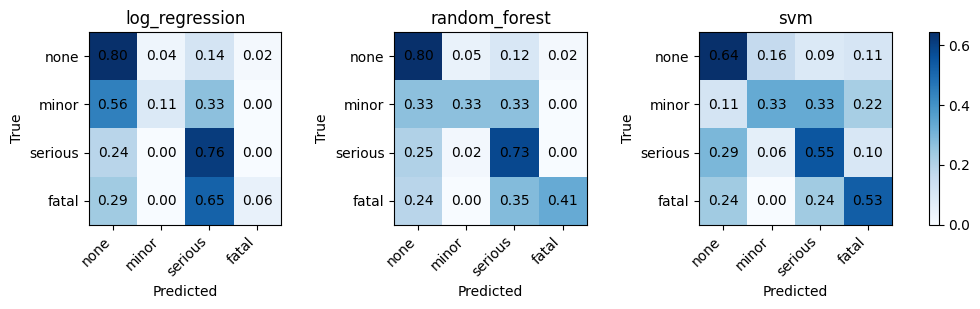

Confusion Matrices for Question 2:


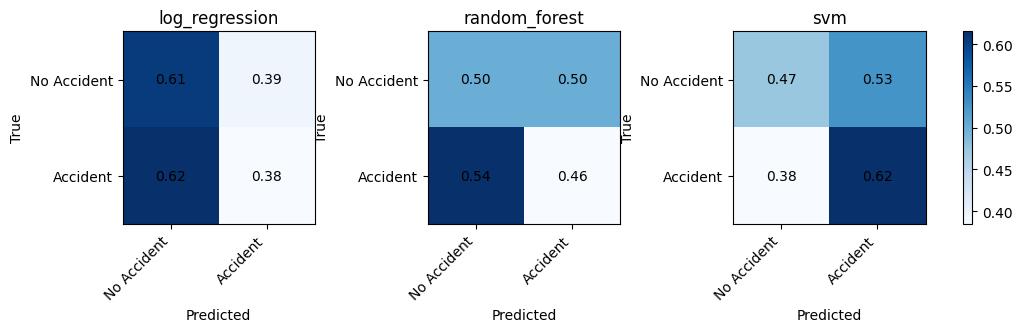

In [4]:
def plot_confusion_matrices(results_by_model, question_key, normalize=False, figsize=(12, 2.5)):
    model_names = list(results_by_model.keys())
    n = len(model_names)

    fig, axes = plt.subplots(1, n, figsize=figsize, squeeze=False)
    axes = axes[0]

    for ax, model in zip(axes, model_names):
        q = results_by_model[model].get(question_key, {})
        cm = q.get("confusion_matrix", {}) or {}
        labels = cm.get("labels", None)
        mat = np.array(cm.get("matrix", []), dtype=float)

        if mat.size == 0:
            ax.set_title(f"{model}\n(no CM)")
            ax.axis("off")
            continue

        if normalize:
            row_sums = mat.sum(axis=1, keepdims=True)
            mat = np.divide(mat, row_sums, out=np.zeros_like(mat), where=row_sums != 0)

        im = ax.imshow(mat, interpolation="nearest", cmap="Blues")
        ax.set_title(model)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

        if labels is not None:
            ax.set_xticks(np.arange(len(labels)))
            ax.set_yticks(np.arange(len(labels)))
            ax.set_xticklabels(labels, rotation=45, ha="right")
            ax.set_yticklabels(labels)

        # annotate
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = mat[i, j]
                txt = f"{val:.2f}" if normalize else f"{int(val)}"
                ax.text(j, i, txt, ha="center", va="center")

    fig.colorbar(im, ax=axes, fraction=0.03, pad=0.04)
    plt.show()

print("Confusion Matrices for Question 1:")
plot_confusion_matrices(results_by_model, "question_1", normalize=True)
print("Confusion Matrices for Question 2:")
plot_confusion_matrices(results_by_model, "question_2", normalize=True)

# Side-by-side ROC Curves

ROC Curves for Question 1:


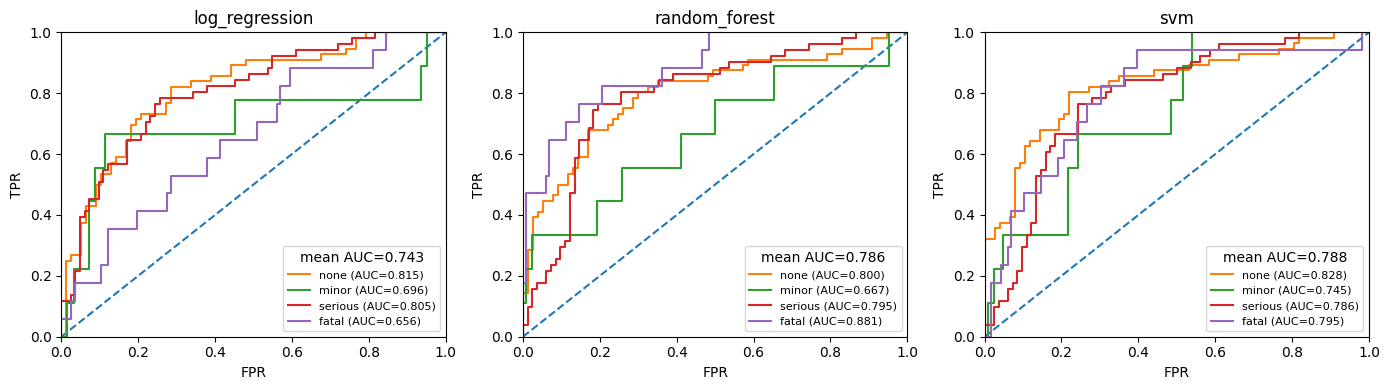

ROC Curves for Question 2:


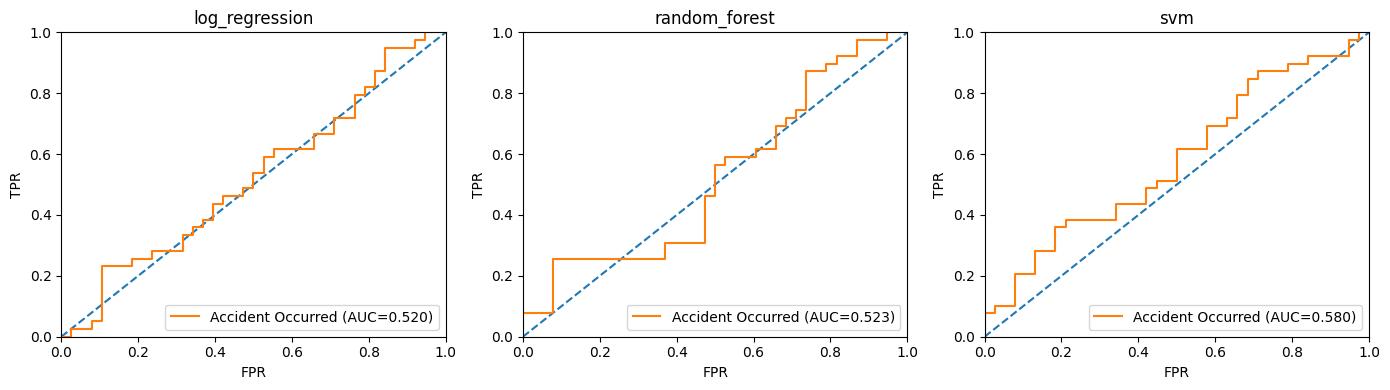

In [5]:
def plot_roc_side_by_side(results_by_model, question_key, figsize=(14, 4)):
    model_names = list(results_by_model.keys())
    n = len(model_names)

    fig, axes = plt.subplots(1, n, figsize=figsize, squeeze=False)
    axes = axes[0]

    for ax, model in zip(axes, model_names):
        q = results_by_model[model].get(question_key, {})
        roc = (q.get("roc_curve", {}) or {})

        ax.plot([0, 1], [0, 1], linestyle="--")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_title(model)
        ax.set_xlabel("FPR")
        ax.set_ylabel("TPR")

        if "binary" in roc and isinstance(roc["binary"], dict):
            d = roc["binary"]
            fpr = np.array(d.get("fpr", []), dtype=float)
            tpr = np.array(d.get("tpr", []), dtype=float)
            auc = d.get("roc_auc", None)
            label = d.get("label", "positive")
            ax.plot(fpr, tpr, label=f"{label} (AUC={auc:.3f})" if auc is not None else label)
            ax.legend(loc="lower right")

        elif "multiclass" in roc and isinstance(roc["multiclass"], dict):
            aucs = []
            for cls, d in roc["multiclass"].items():
                fpr = np.array(d.get("fpr", []), dtype=float)
                tpr = np.array(d.get("tpr", []), dtype=float)
                auc = d.get("roc_auc", None)
                aucs.append(auc if auc is not None else np.nan)
                ax.plot(fpr, tpr, label=f"{cls} (AUC={auc:.3f})" if auc is not None else str(cls))
            m = np.nanmean(aucs) if len(aucs) else np.nan
            ax.legend(loc="lower right", fontsize=8, title=f"mean AUC={m:.3f}" if not np.isnan(m) else None)

        else:
            ax.text(0.5, 0.5, "No ROC data", ha="center", va="center")

    plt.tight_layout()
    plt.show()

print("ROC Curves for Question 1:")
plot_roc_side_by_side(results_by_model, "question_1")
print("ROC Curves for Question 2:")
plot_roc_side_by_side(results_by_model, "question_2")

# Side-by-side Feature Importances

Feature Importances for Question 1:


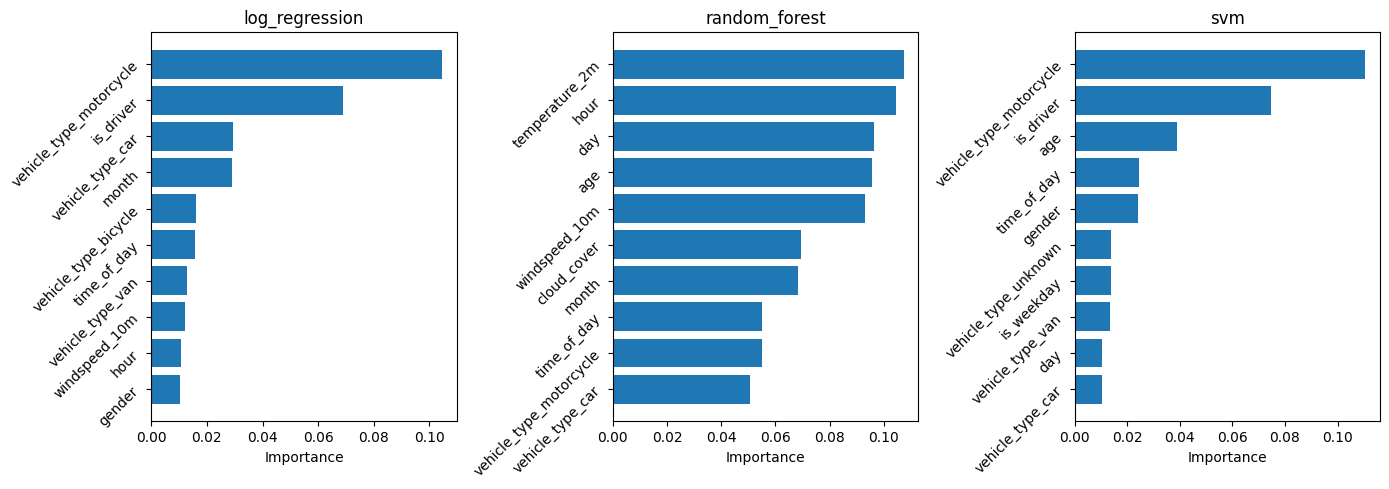

Feature Importances for Question 2:


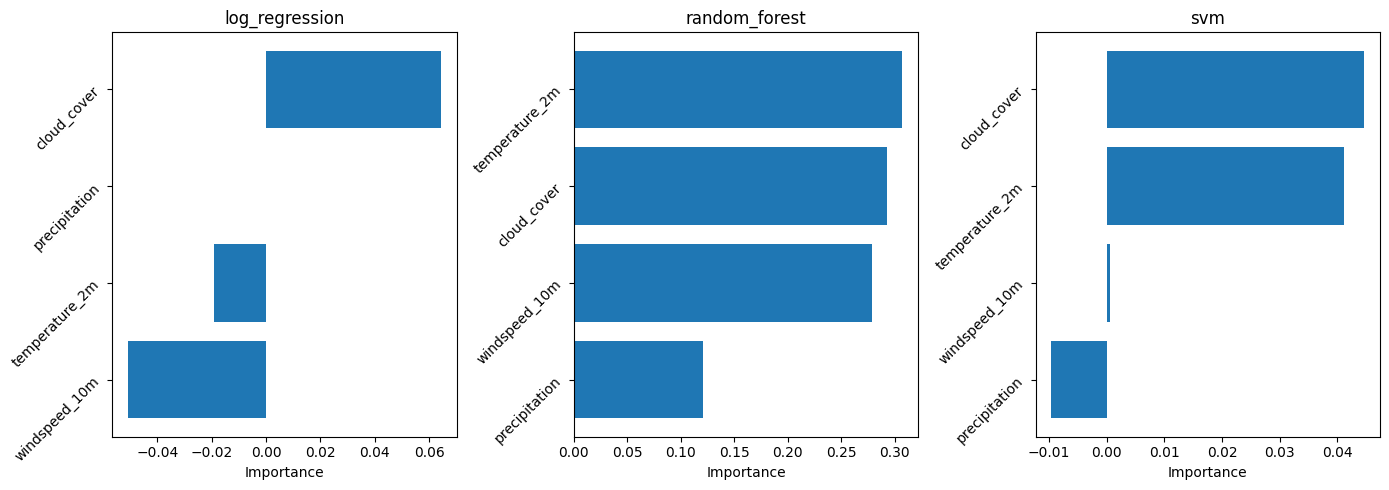

In [6]:
def plot_feature_importances(results_by_model, question_key, top_k=15, figsize=(14, 5)):
    model_names = list(results_by_model.keys())
    n = len(model_names)

    fig, axes = plt.subplots(1, n, figsize=figsize, squeeze=False)
    axes = axes[0]

    for ax, model in zip(axes, model_names):
        q = results_by_model[model].get(question_key, {})
        fi = q.get("feature_importances", None)

        if not fi:
            ax.set_title(f"{model}\n(no importances)")
            ax.axis("off")
            continue

        df = pd.DataFrame(fi).copy()
        df["importance"] = df["importance"].astype(float)
        df = df.sort_values("importance", ascending=False).head(top_k)
        df = df.iloc[::-1]  # so biggest at top after barh
        df["feature"] = df["feature"].apply(lambda x: x.split("__", 1)[-1])

        ax.barh(df["feature"], df["importance"])
        ax.set_title(model)
        ax.set_xlabel("Importance")
        ax.tick_params("y", rotation=45)

    plt.tight_layout()
    plt.show()

print("Feature Importances for Question 1:")
plot_feature_importances(results_by_model, "question_1", top_k=10)
print("Feature Importances for Question 2:")
plot_feature_importances(results_by_model, "question_2", top_k=10)

# Statistical correlations
## Stuart-Maxwell Test for multi-class correlations

In [7]:
from statsmodels.stats.contingency_tables import SquareTable

def create_model_comparison_matrix(preds_a, preds_b, num_classes):
    matrix = np.zeros((num_classes, num_classes), dtype=int)
    for a, b in zip(preds_a, preds_b):
        matrix[a, b] += 1
    return matrix

def highlight_diff_only(data):
    # Create a mask of empty strings (no style)
    mask = pd.DataFrame('', index=data.index, columns=data.columns)
    
    for row in data.index:
        for col in data.columns:
            if row != col:
                if data.loc[row, col] < 0.05:
                    mask.loc[row, col] = 'background-color: green'
                else:
                    mask.loc[row, col] = 'background-color: transparent'
            else:
                mask.loc[row, col] = 'color: grey'
                
    return mask

q1_y_true = list(results_by_model.values())[0]["question_1"]["y_true"]
q1_model_preds = {k: v["question_1"]["y_pred"] for k, v in results_by_model.items()}
model_names = list(q1_model_preds.keys())
p_matrix = pd.DataFrame(index=model_names, columns=model_names)
num_classes = max(q1_y_true) + 1

for model_a_name, model_a_y in q1_model_preds.items():
    for model_b_name, model_b_y in q1_model_preds.items():
        table_data = create_model_comparison_matrix(model_a_y, model_b_y, num_classes)
        sq_table = SquareTable(table_data)
        test_results = sq_table.homogeneity()
        p_matrix.loc[model_a_name, model_b_name] = test_results.pvalue
            
print("P-Value Matrix for Question 1:")
p_matrix.style.apply(highlight_diff_only, axis=None).format("{:.4f}").set_caption("P-Values (Green = Significant)")

P-Value Matrix for Question 1:


,log_regression,random_forest,svm
log_regression,1.0000,0.1438,0.0000
random_forest,0.1438,1.0000,0.0005
svm,0.0000,0.0005,1.0000


## McNemar correlation for binary classification

In [8]:
from mlxtend.evaluate import mcnemar_table, mcnemar

def compute_mcnemar(y_true, y_pred_a, y_pred_b):
    table = mcnemar_table(y_target=np.array(y_true),
                          y_model1=np.array(y_pred_a),
                          y_model2=np.array(y_pred_b))
    
    chi2, p = mcnemar(ary=table, corrected=True)
    return float(chi2), float(p)

q2_y_true = list(results_by_model.values())[0]["question_2"]["y_true"]
q2_model_preds = {k: v["question_2"]["y_pred"] for k, v in results_by_model.items()}
model_names = list(q2_model_preds.keys())
p_matrix = pd.DataFrame(index=model_names, columns=model_names)

for model_a_name, model_a_y in q2_model_preds.items():
    for model_b_name, model_b_y in q2_model_preds.items():
        if model_a_name == model_b_name:
            p_matrix.loc[model_a_name, model_b_name] = 1.0
            continue
        chi2, p = compute_mcnemar(q2_y_true, model_a_y, model_b_y)
        p_matrix.loc[model_a_name, model_b_name] = p
        
p_matrix.style.apply(highlight_diff_only, axis=None).format("{:.4f}").set_caption("P-Values (Green = Significant)")

,log_regression,random_forest,svm
log_regression,1.0000,1.0000,0.5839
random_forest,1.0000,1.0000,0.3017
svm,0.5839,0.3017,1.0000
